<a href="https://colab.research.google.com/github/raj005-gitH/AI-ML-Google-Collab/blob/main/regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    ExtraTreesRegressor
)

from sklearn.svm import SVR

#Evaluation Metrics
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_error
)




In [6]:
df = pd.read_csv('/content/house_price_regression_dataset.csv')
print(df.head(5))


   Square_Footage  Num_Bedrooms  Num_Bathrooms  Year_Built  Lot_Size  \
0            1360             2              1        1981  0.599637   
1            4272             3              3        2016  4.753014   
2            3592             1              2        2016  3.634823   
3             966             1              2        1977  2.730667   
4            4926             2              1        1993  4.699073   

   Garage_Size  Neighborhood_Quality   House_Price  
0            0                     5  2.623829e+05  
1            1                     6  9.852609e+05  
2            0                     9  7.779774e+05  
3            1                     8  2.296989e+05  
4            0                     8  1.041741e+06  


In [7]:
print(df.columns.tolist())


['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built', 'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price']


In [10]:
TARGET_COLUMN = "House_Price"

X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]

print(X.head())
print(y.head())

   Square_Footage  Num_Bedrooms  Num_Bathrooms  Year_Built  Lot_Size  \
0            1360             2              1        1981  0.599637   
1            4272             3              3        2016  4.753014   
2            3592             1              2        2016  3.634823   
3             966             1              2        1977  2.730667   
4            4926             2              1        1993  4.699073   

   Garage_Size  Neighborhood_Quality  
0            0                     5  
1            1                     6  
2            0                     9  
3            1                     8  
4            0                     8  
0    2.623829e+05
1    9.852609e+05
2    7.779774e+05
3    2.296989e+05
4    1.041741e+06
Name: House_Price, dtype: float64


In [21]:
print(y.head())


0    2.623829e+05
1    9.852609e+05
2    7.779774e+05
3    2.296989e+05
4    1.041741e+06
Name: House_Price, dtype: float64


In [24]:
X = pd.get_dummies(X, drop_first=True)
print(X.head())

   Square_Footage  Num_Bedrooms  Num_Bathrooms  Year_Built  Lot_Size  \
0            1360             2              1        1981  0.599637   
1            4272             3              3        2016  4.753014   
2            3592             1              2        2016  3.634823   
3             966             1              2        1977  2.730667   
4            4926             2              1        1993  4.699073   

   Garage_Size  Neighborhood_Quality  
0            0                     5  
1            1                     6  
2            0                     9  
3            1                     8  
4            0                     8  


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [60]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [51]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regressison": Ridge(),
    "Lasso Regression": Lasso(),
    "KNN Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "Extra Trees": ExtraTreesRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42),
    "SVR": SVR()
}

In [56]:
results = []
for name, model in models.items():

  # Models requiring scaled data
  if name in [
      "KNN Regressor",
      "Decision Tree",
      "Random Forest",
      "Gradient Boosting",
      "Extra Trees",
      "AdaBoost",
      "Linear Regression",
      "Ridge Regressison",
      "Lasso Regression",
      "SVR"
  ]:
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
  else:
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

  # Evaluation Metrics
  mae = mean_absolute_error(y_test, pred)
  mse = mean_squared_error(y_test, pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_test, pred)

  results.append([model, name, mae, mse, r2])
  print(results)

[[LinearRegression(), 'Linear Regression', 8174.5835999305455, 101434798.45305042, 0.9984263636831646]]
[[LinearRegression(), 'Linear Regression', 8174.5835999305455, 101434798.45305042, 0.9984263636831646], [Ridge(), 'Ridge Regressison', 8241.58690994935, 102480989.96052475, 0.9984101333068477]]
[[LinearRegression(), 'Linear Regression', 8174.5835999305455, 101434798.45305042, 0.9984263636831646], [Ridge(), 'Ridge Regressison', 8241.58690994935, 102480989.96052475, 0.9984101333068477], [Lasso(), 'Lasso Regression', 8174.748373738497, 101436558.12751551, 0.9984263363839766]]
[[LinearRegression(), 'Linear Regression', 8174.5835999305455, 101434798.45305042, 0.9984263636831646], [Ridge(), 'Ridge Regressison', 8241.58690994935, 102480989.96052475, 0.9984101333068477], [Lasso(), 'Lasso Regression', 8174.748373738497, 101436558.12751551, 0.9984263363839766], [KNeighborsRegressor(), 'KNN Regressor', 69823.26478340001, 6986408437.449158, 0.8916144537271055]]
[[LinearRegression(), 'Linear Regr

In [57]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score"
    ]
)



results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

print(results_df)

                                               Model                MAE  \
0                                 LinearRegression()  Linear Regression   
2                                            Lasso()   Lasso Regression   
1                                            Ridge()  Ridge Regressison   
6  ([DecisionTreeRegressor(criterion='friedman_ms...  Gradient Boosting   
7  (ExtraTreeRegressor(random_state=1608637542), ...        Extra Trees   
5  (DecisionTreeRegressor(max_features=1.0, rando...      Random Forest   
4                            DecisionTreeRegressor()      Decision Tree   
8  (DecisionTreeRegressor(max_depth=3, random_sta...           AdaBoost   
3                              KNeighborsRegressor()      KNN Regressor   
9                                              SVR()                SVR   

             MSE          RMSE  R2 Score  
0    8174.583600  1.014348e+08  0.998426  
2    8174.748374  1.014366e+08  0.998426  
1    8241.586910  1.024810e+08  0.998410  
6 

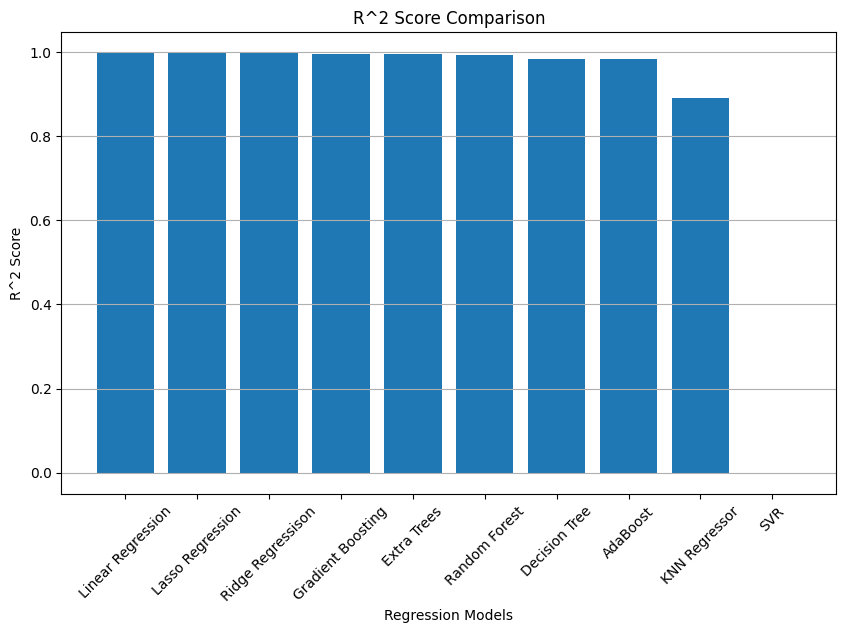

In [64]:
import matplotlib.pyplot as plt

#Sort by R^2 Score
results_df = results_df.sort_values(by="R2 Score", ascending=False)

plt.figure(figsize=(10,6))
plt.bar(results_df["MAE"], results_df["R2 Score"])
plt.title("R^2 Score Comparison")
plt.xlabel("Regression Models")
plt.ylabel("R^2 Score")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()